# OG statystyki

In [37]:
def print_og_network_stats():
    n = 3892
    e = 17262
    density_ba = 0.002280
    num_components_ba = 1
    avg_path_ba = 6.2759
    diameter_ba = 20
    deg_min, deg_max, deg_avg = 1, 126, 8.87

    print(f"--- WYNIKI DLA MODELU OG ---")
    print(f"n={n}, e={e}")
    print(f"Gęstość: {density_ba:.6f}")
    print(f"Liczba składowych: {num_components_ba}")
    print(f"Średnia długość ścieżki: {avg_path_ba:.4f}")
    print(f"Średnica: {diameter_ba}")
    print(f"Stopień min: {deg_min}, max: {deg_max}, średni: {deg_avg:.2f}")


# Rozruch

In [39]:
import networkx as nx

n = 3892
target_edges = 17262

#
p = target_edges / (n * (n - 1) / 2)
g_erd_ren = nx.erdos_renyi_graph(n, p)

# Barabasi-Albert
# m=4 daje koło 15.5k krawędzi m=5 19.4k
m = 4
g_ba = nx.barabasi_albert_graph(n, m)


print(f"OG: n=3892, e=17262")
print(f"erdos renyi: n={g_erd_ren.number_of_nodes()}, e={g_erd_ren.number_of_edges()}")
print(f"BA:      n={g_ba.number_of_nodes()}, e={g_ba.number_of_edges()}")

OG: n=3892, e=17262
erdos renyi: n=3892, e=17194
BA:      n=3892, e=15552


### fcja statystykująca

In [53]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def analyze_graph(G, name="OG"):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    density_ba = nx.density(G)
    num_components_ba = nx.number_connected_components(G)

    if nx.is_connected(G):
        diameter_ba = nx.diameter(G)
        avg_path_ba = nx.average_shortest_path_length(G)
    else:
        diameter_ba = "Niespójny"
        avg_path_ba = "Niespójny"

    degrees = [d for n, d in G.degree()]
    deg_min = min(degrees) if degrees else 0
    deg_max = max(degrees) if degrees else 0
    deg_avg = sum(degrees) / n if n > 0 else 0

    print(f"--- WYNIKI DLA MODELU {name} ---")
    print(f"n={n}, e={e}")
    print(f"Gęstość: {density_ba:.6f}")
    print(f"Liczba składowych: {num_components_ba}")

    if isinstance(avg_path_ba, (float, int)):
        print(f"Średnia długość ścieżki: {avg_path_ba:.4f}")
    else:
        print(f"Średnia długość ścieżki: {avg_path_ba}")

    print(f"Średnica: {diameter_ba}")
    print(f"Stopień min: {deg_min}, max: {deg_max}, średni: {deg_avg:.2f}")
    print("-" * 30)


    print_og_network_stats()

    deg_centrality = list(nx.degree_centrality(G).values())
    close_centrality = list(nx.closeness_centrality(G).values())
    bet_centrality = list(nx.betweenness_centrality(G).values())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Analiza centralności - {name}', fontsize=16)

    titles = ['Degree Centrality', 'Closeness Centrality', 'Betweenness Centrality']
    data = [deg_centrality, close_centrality, bet_centrality]
    colors = ['orange', 'skyblue', 'lightgreen']

    for ax, d, title, color in zip(axes, data, titles, colors):
        ax.hist(d, bins=50, color=color, edgecolor='black', alpha=0.7)
        ax.set_title(title)
        ax.set_yscale('log')
        ax.set_xlabel('Wartość')
        ax.set_ylabel('Liczba wierzchołków (log)')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    display(Image(filename='OG_nodes.png'))



# BA

--- WYNIKI DLA MODELU Barabasi-Albert ---
n=3892, e=15552
Gęstość: 0.002054
Liczba składowych: 1
Średnia długość ścieżki: 3.5996
Średnica: 6
Stopień min: 4, max: 196, średni: 7.99
------------------------------
--- WYNIKI DLA MODELU OG ---
n=3892, e=17262
Gęstość: 0.002280
Liczba składowych: 1
Średnia długość ścieżki: 6.2759
Średnica: 20
Stopień min: 1, max: 126, średni: 8.87


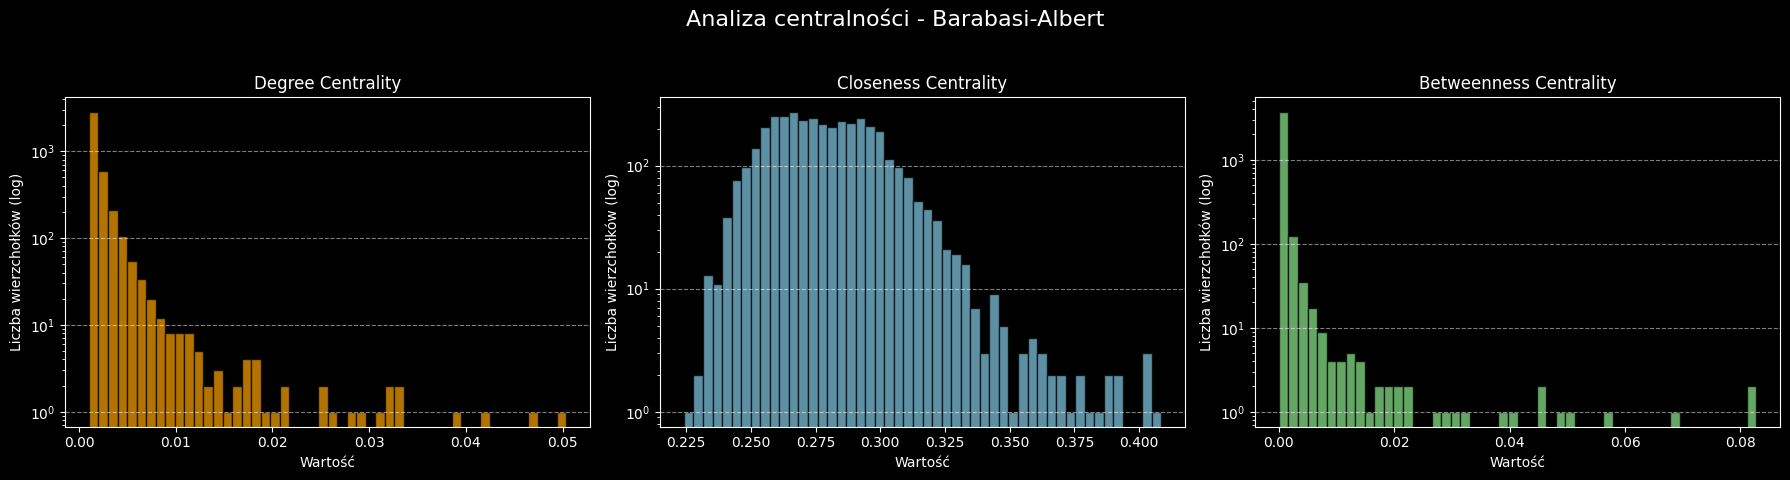

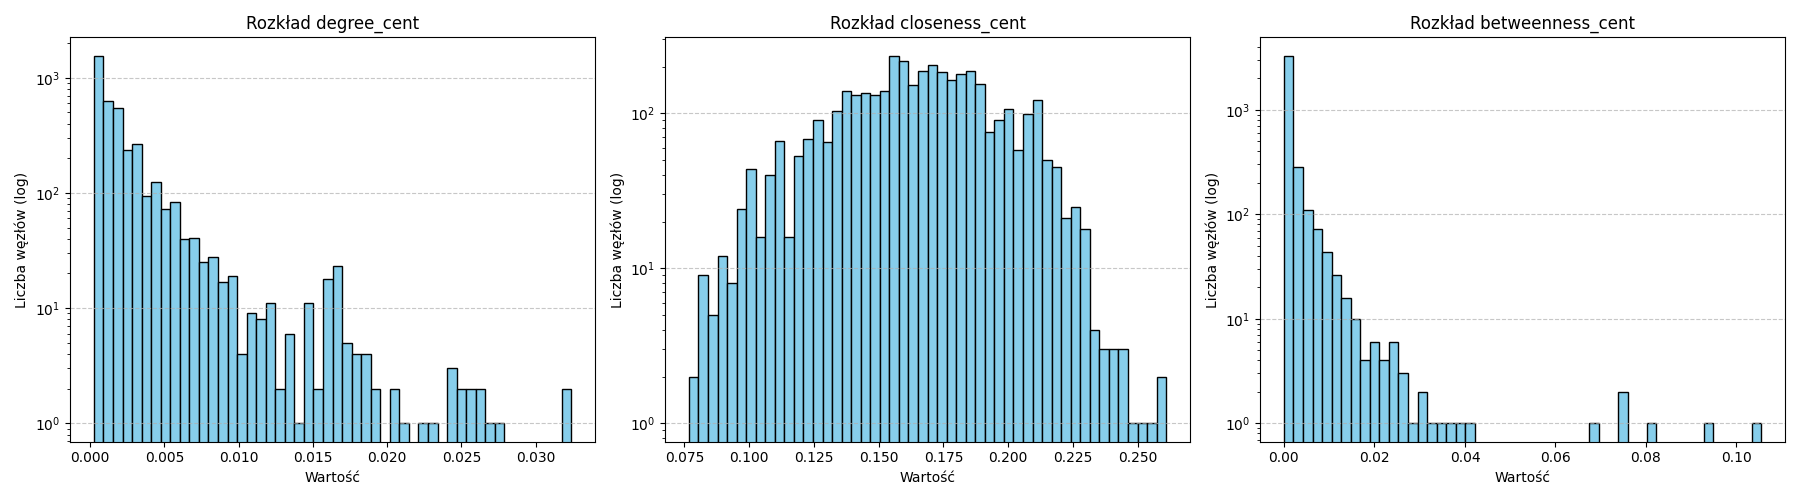

In [54]:
analyze_graph(g_ba, "Barabasi-Albert")

# ER

--- WYNIKI DLA MODELU Erdos renyi ---
n=3892, e=17194
Gęstość: 0.002271
Liczba składowych: 4
Średnia długość ścieżki: Niespójny
Średnica: Niespójny
Stopień min: 0, max: 21, średni: 8.84
------------------------------
--- WYNIKI DLA MODELU OG ---
n=3892, e=17262
Gęstość: 0.002280
Liczba składowych: 1
Średnia długość ścieżki: 6.2759
Średnica: 20
Stopień min: 1, max: 126, średni: 8.87


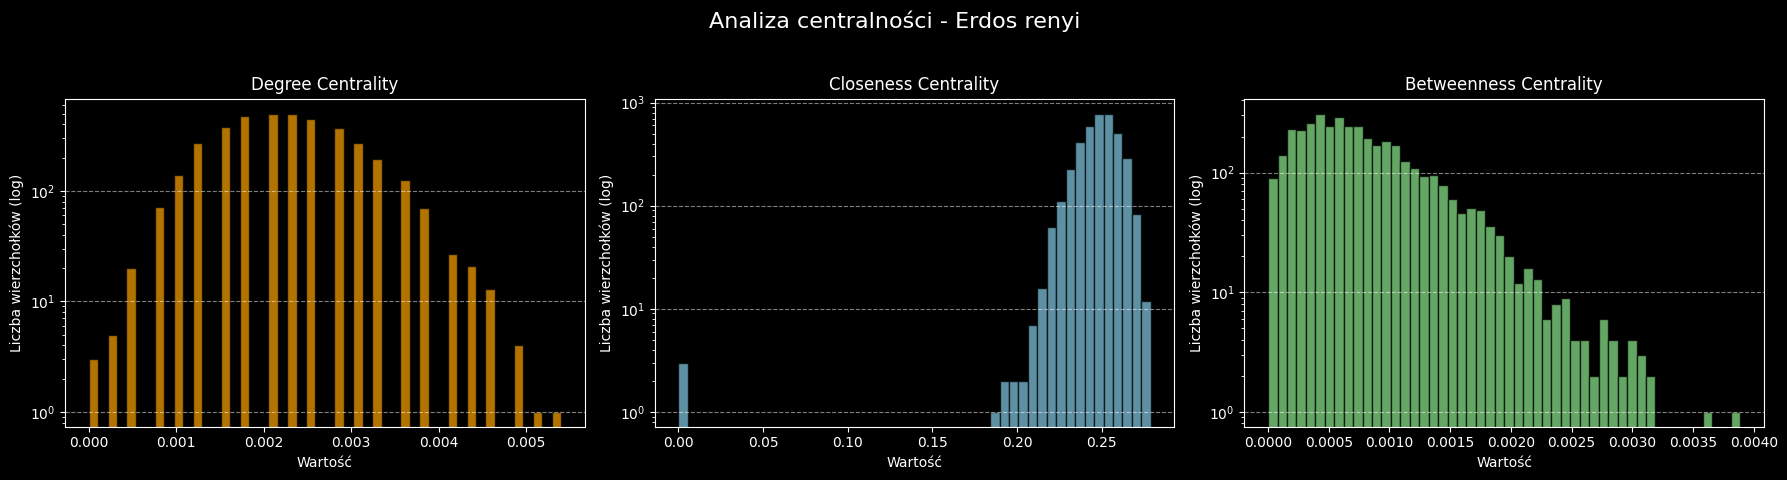

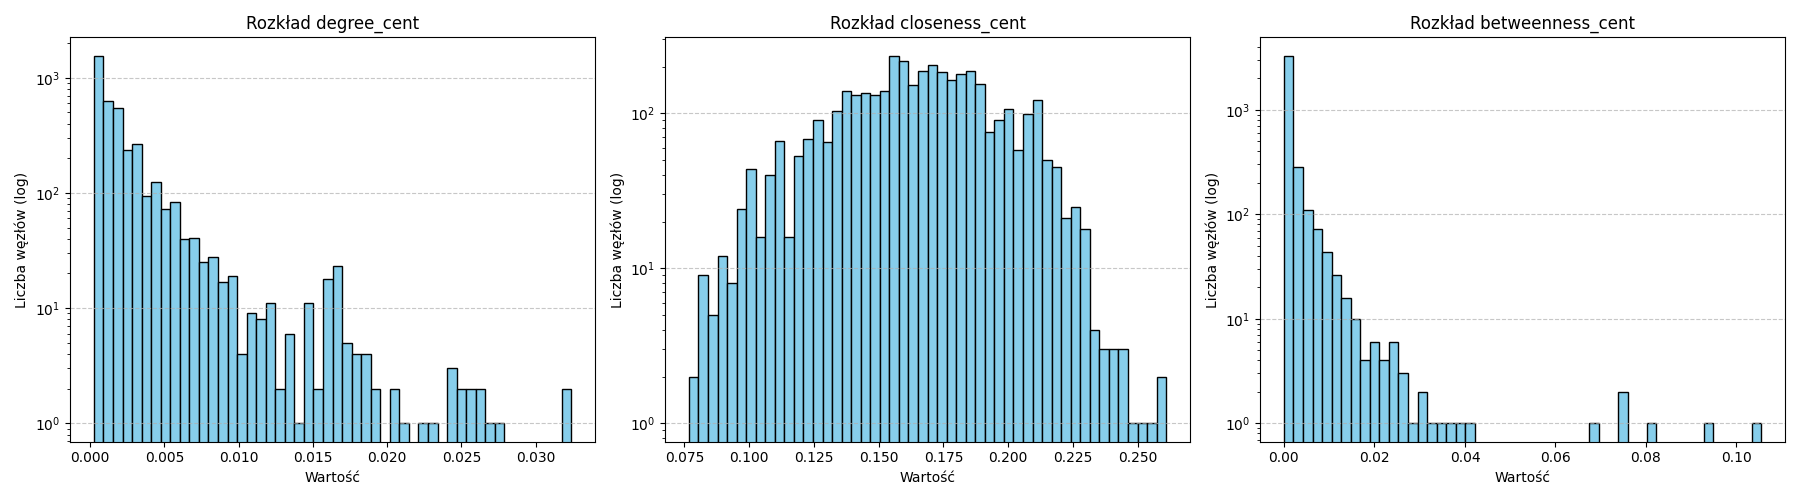

In [55]:
analyze_graph(g_erd_ren, "Erdos renyi")

# Grupowanie